![Google Play Store](play-store.jpg) 
# Google Play Store App Analysis

## Overview

This project analyzes applications available on the Google Play Store to identify trends in app performance, user engagement, ratings, and market categories. The analysis aims to support business stakeholders in understanding what factors contribute to successful applications and how different app categories perform in the marketplace. Findings from this project will inform recommendations for app developers, marketers, and business decision-makers.

## Business Understanding

The mobile application industry is highly competitive, with millions of applications competing for user attention. Understanding the characteristics associated with successful applications can help developers and businesses make informed decisions regarding app development, pricing strategies, and category selection.

Stakeholders include:

- App Developers
- Product Managers
- Marketing Teams
- Business Executives

Key business questions include:

1. Which app categories attract the highest number of installs?
2. How do ratings vary across app categories?
3. Is there a relationship between app price and user ratings?
4. Which categories generate the greatest user engagement?
5. What characteristics are common among highly rated applications?

## Data Understanding
- Present the source of data
- Describe the data available
- What is relevant to keep what is not
- Present any data cleaning that needs to happen
- Null values? Type mismatches? Duplicates?

In [23]:

import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, count, sum, when
from pyspark.sql.window import Window
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

In [4]:
# EDA Code Here - Create New Cells As Needed
spark = SparkSession.builder.appName("PlayStoreAnalysis").getOrCreate()

df_spark = spark.read.csv("google_play_store_dataset.csv", header=True, inferSchema=True)

df_spark.printSchema()
df_spark.show(5)

root
 |-- App: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Rating: string (nullable = true)
 |-- Reviews: string (nullable = true)
 |-- Size: string (nullable = true)
 |-- Installs: string (nullable = true)
 |-- Type: string (nullable = true)
 |-- Price: string (nullable = true)
 |-- Content Rating: string (nullable = true)
 |-- Genres: string (nullable = true)
 |-- Last Updated: string (nullable = true)
 |-- Current Ver: string (nullable = true)
 |-- Android Ver: string (nullable = true)

+--------------------+--------------+------+-------+----+-----------+----+-----+--------------+--------------------+----------------+------------------+------------+
|                 App|      Category|Rating|Reviews|Size|   Installs|Type|Price|Content Rating|              Genres|    Last Updated|       Current Ver| Android Ver|
+--------------------+--------------+------+-------+----+-----------+----+-----+--------------+--------------------+----------------+--------------

## Data Preparation



In [7]:
# Data Prep Code Here
df = pd.read_csv("google_play_store_dataset.csv")
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [9]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [10]:
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.dropna(inplace=True)

In [14]:
df['Installs'] = df['Installs'].str.replace(',', '')
df['Installs'] = df['Installs'].str.replace('+', '')
df['Installs'] = df['Installs'].astype(int)

In [15]:
df['Price'] = df['Price'].str.replace('$', '')
df['Price'] = df['Price'].astype(float)

In [25]:
df['Size'] = df['Size'].str.replace('M', '')
df['Size'] = df['Size'].replace('Varies with device', np.nan)
df['Size'] = pd.to_numeric(df['Size'], errors='coerce')

## Data Analysis

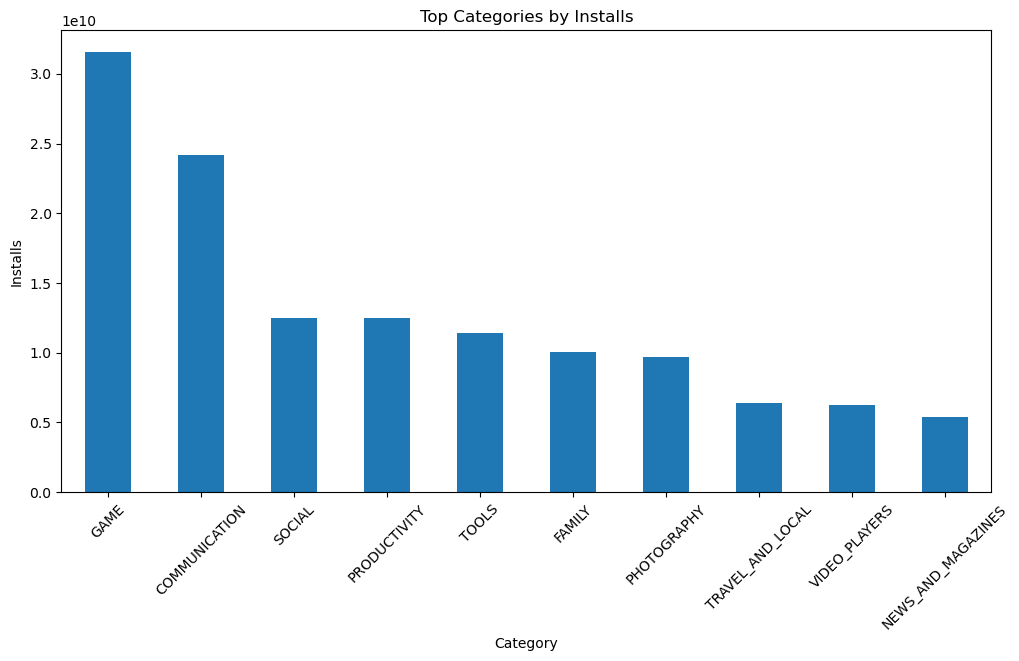

In [18]:
top_installs = df.groupby("Category")["Installs"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
top_installs.head(10).plot(kind='bar')
plt.title("Top Categories by Installs")
plt.ylabel("Installs")
plt.xticks(rotation=45)
plt.show()

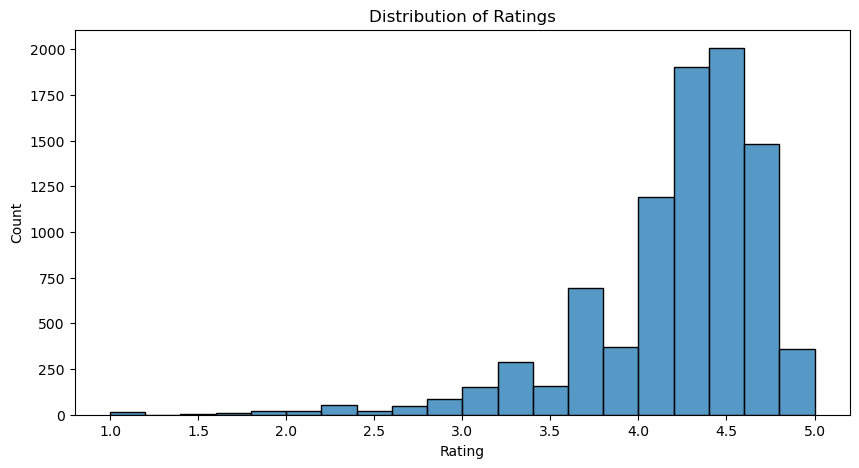

In [24]:
plt.figure(figsize=(10,5))
sns.histplot(df['Rating'], bins=20)
plt.title("Distribution of Ratings")
plt.show()

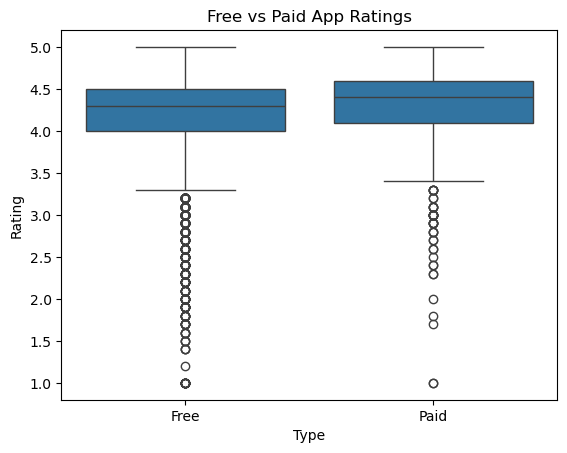

In [27]:
sns.boxplot(x='Type', y='Rating', data=df)
plt.title("Free vs Paid App Ratings")
plt.show()

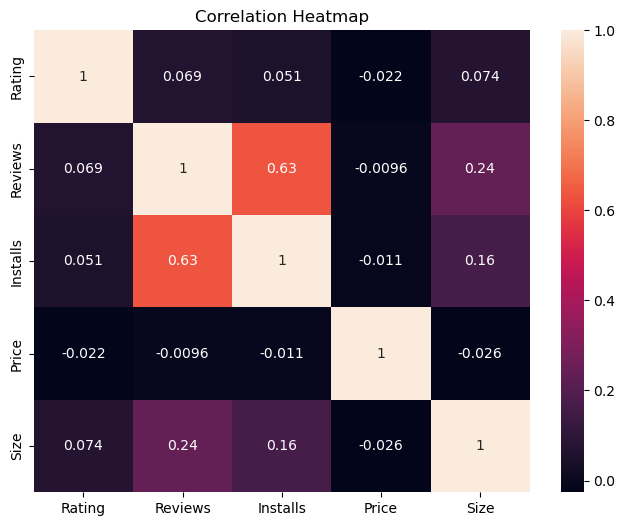

In [28]:
numeric_df = df[['Rating','Reviews','Installs','Price','Size']]

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
top_reviews = df.sort_values(
    by='Reviews',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x='Reviews',
    y='App',
    data=top_reviews
)

plt.title("Top Reviewed Apps")

plt.show()

In [29]:
# Save cleaned data file for Tableau usage
df.to_csv("cleaned_google_play_store.csv", index=False)

In [30]:
spark.stop()

### Tableau Dashboard Link

[View my Tableau Public Dashboard](https://public.tableau.com/app/profile/martin.mwapahe/viz/Googleplayanalysis_17811028991470/MainDashboard)

### Interactive Dashboard Development
#### Objective

The goal of this phase is to translate analytical insights from the Google Play Store dataset into an interactive and user-friendly dashboard using Tableau. The dashboard will allow stakeholders to explore app performance trends, category distributions and user engagement metrics.

#### Dashboard Design Plan

The dashboard will include the following key components:

1. Category Performance Overview
- Total installs per category
- Average rating per category
- Top-performing categories
2. App Type Analysis
- Comparison between Free and Paid apps
- Installs distribution by app type
- Rating differences between types
3. User Engagement Analysis
- Relationship between Reviews and Ratings
- Most reviewed apps
- Engagement trends across categories
4. Genre Distribution
- Most common app genres
- Genre popularity based on installs and ratings
- Interactivity Features

#### Design Principles
- Maintain a clean and minimal layout
- Use consistent color themes for readability
- Ensure charts are clearly labeled and easy to interpret
- Focus on storytelling rather than cluttered visuals

### Summative Findings & Conclusion
#### Objective

This phase summarizes the key insights derived from the analysis and highlights business implications for stakeholders.

#### Key Findings
- The Games and Communication categories dominate in terms of total installs, indicating high user demand in entertainment and connectivity.
- Educational and Event-based applications show higher average ratings, suggesting strong user satisfaction in these categories.
- Free applications significantly outperform paid applications in terms of total installs, reinforcing the importance of freemium models in mobile app strategy.
- There is a weak positive relationship between the number of reviews and app ratings, indicating that engagement does not strongly guarantee higher satisfaction.
- Certain genres, particularly Action and Entertainment, dominate the Play Store ecosystem.
Business Implications
- Developers should prioritize high-demand categories such as Games and Communication to maximize reach.
Improving user experience in Education and Events categories can strengthen user retention.
- Pricing strategy should be carefully evaluated, as paid apps do not necessarily lead to higher ratings or engagement.
- Marketing efforts should focus on increasing visibility and engagement rather than relying solely on app pricing.

#### Limitations
- Some missing values were present in the dataset and required cleaning.
- Certain columns such as Size contained inconsistent formats and approximations.
- Ratings may be influenced by external factors not captured in the dataset.

#### Final Conclusion

This analysis provides a comprehensive overview of the Google Play Store ecosystem, highlighting key trends in app performance, user engagement, and category distribution. The findings can support data-driven decision-making for app developers, marketers, and platform strategists aiming to improve app success and user satisfaction.